# EDA — Palmer Penguins
**Розвідувальний аналіз даних (Exploratory Data Analysis)**

Набір даних: 344 пінгвіни трьох видів (Adelie, Chinstrap, Gentoo) з трьох островів архіпелагу Палмера (Антарктида). Сучасна заміна класичного Iris.

Мета: пройти повний цикл EDA — завантаження → перевірка якості → одновимірний аналіз → двовимірний аналіз → висновки.

## 1. Імпорти та налаштування

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style='whitegrid')
plt.rcParams['figure.figsize'] = (8, 5)

## 2. Завантаження даних та перший погляд

In [2]:
df = sns.load_dataset('penguins')
df.head()

,species,island,bill_length_mm,bill_depth_mm,flipper_length_mm,body_mass_g,sex
0,Adelie,Torgersen,39.1,18.7,181.0,3750.0,Male
1,Adelie,Torgersen,39.5,17.4,186.0,3800.0,Female
2,Adelie,Torgersen,40.3,18.0,195.0,3250.0,Female
3,Adelie,Torgersen,NaN,NaN,NaN,NaN,NaN
4,Adelie,Torgersen,36.7,19.3,193.0,3450.0,Female


In [3]:
# Розмір: рядки x стовпці
df.shape

(344, 7)

In [4]:
# Типи даних та кількість непорожніх значень
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 344 entries, 0 to 343
Data columns (total 7 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   species            344 non-null    str    
 1   island             344 non-null    str    
 2   bill_length_mm     342 non-null    float64
 3   bill_depth_mm      342 non-null    float64
 4   flipper_length_mm  342 non-null    float64
 5   body_mass_g        342 non-null    float64
 6   sex                333 non-null    str    
dtypes: float64(4), str(3)
memory usage: 18.9 KB


In [5]:
# Описова статистика числових ознак
df.describe()

,bill_length_mm,bill_depth_mm,flipper_length_mm,body_mass_g
count,342.000000,342.000000,342.000000,342.000000
mean,43.921930,17.151170,200.915205,4201.754386
std,5.459584,1.974793,14.061714,801.954536
min,32.100000,13.100000,172.000000,2700.000000
25%,39.225000,15.600000,190.000000,3550.000000
50%,44.450000,17.300000,197.000000,4050.000000
75%,48.500000,18.700000,213.000000,4750.000000
max,59.600000,21.500000,231.000000,6300.000000


In [6]:
# Числові та категоріальні ознаки
num_cols = ['bill_length_mm', 'bill_depth_mm', 'flipper_length_mm', 'body_mass_g']
cat_cols = ['species', 'island', 'sex']

for col in cat_cols:
    print(f'--- {col} ---')
    print(df[col].value_counts(), end='\n\n')

--- species ---
species
Adelie       152
Gentoo       124
Chinstrap     68
Name: count, dtype: int64

--- island ---
island
Biscoe       168
Dream        124
Torgersen     52
Name: count, dtype: int64

--- sex ---
sex
Male      168
Female    165
Name: count, dtype: int64



## 3. Перевірка якості даних
Шукаємо пропуски та дублікати — обов'язковий крок перед будь-яким аналізом.

In [7]:
# Пропущені значення по кожному стовпцю
df.isnull().sum()

species               0
island                0
bill_length_mm        2
bill_depth_mm         2
flipper_length_mm     2
body_mass_g           2
sex                  11
dtype: int64

In [8]:
# Кількість повних дублікатів рядків
df.duplicated().sum()

np.int64(0)

In [9]:
# Видаляємо рядки з пропусками (їх небагато)
df_clean = df.dropna().reset_index(drop=True)
print(f'Було: {df.shape[0]} рядків -> стало: {df_clean.shape[0]} рядків')

Було: 344 рядків -> стало: 333 рядків


## 4. Одновимірний аналіз (Univariate)
Як розподілена кожна ознака окремо.

### 4.1 Числові ознаки — гістограми

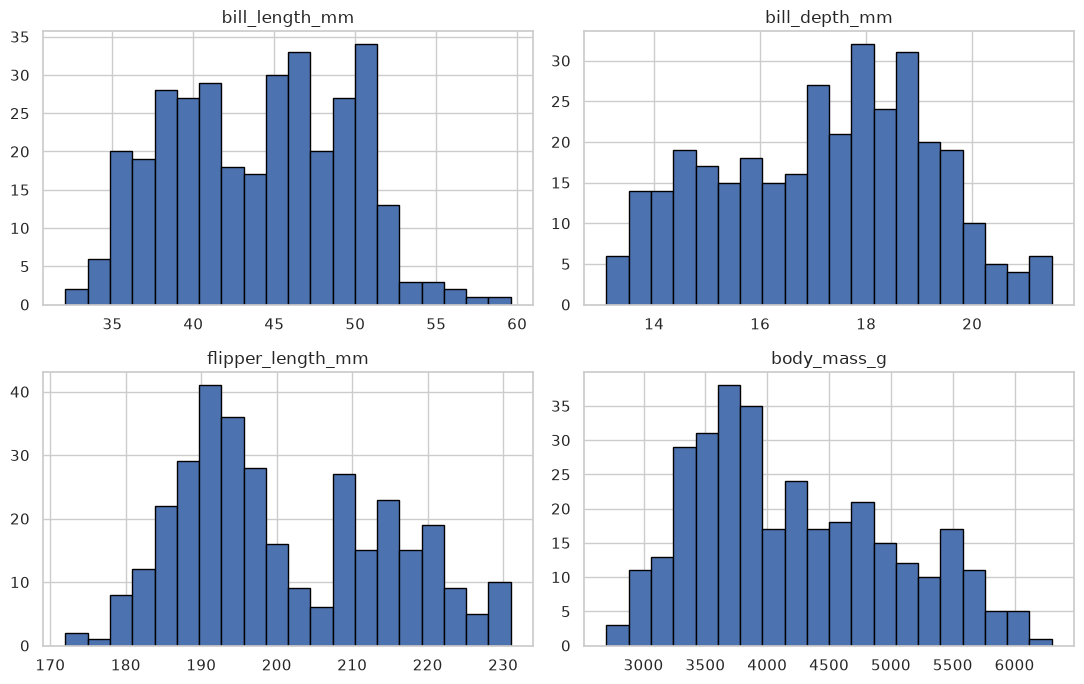

In [10]:
df_clean[num_cols].hist(bins=20, figsize=(11, 7), edgecolor='black')
plt.tight_layout()
plt.show()

### 4.2 Категоріальні ознаки — стовпчикові діаграми

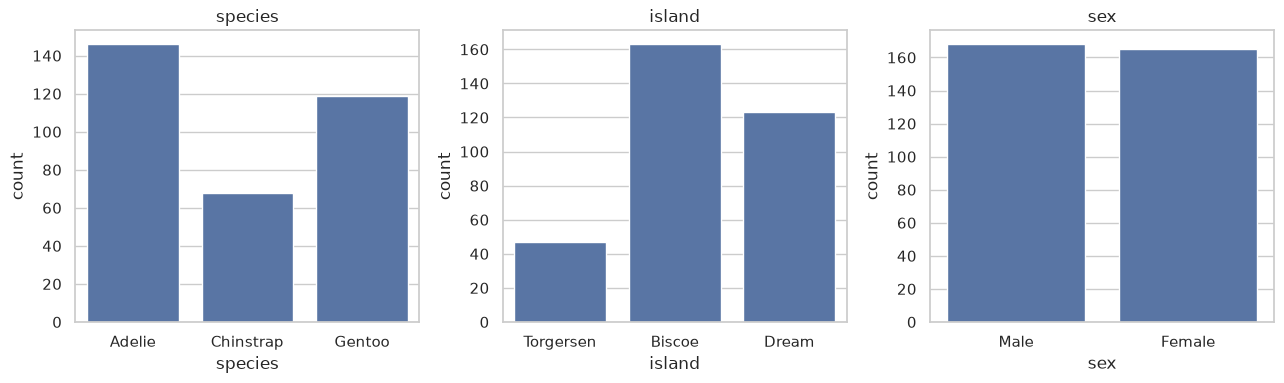

In [11]:
fig, axes = plt.subplots(1, 3, figsize=(13, 4))
for ax, col in zip(axes, cat_cols):
    sns.countplot(data=df_clean, x=col, ax=ax)
    ax.set_title(col)
plt.tight_layout()
plt.show()

## 5. Двовимірний аналіз (Bivariate)
Як ознаки пов'язані між собою та з видом пінгвіна.

### 5.1 Маса тіла за видами — boxplot

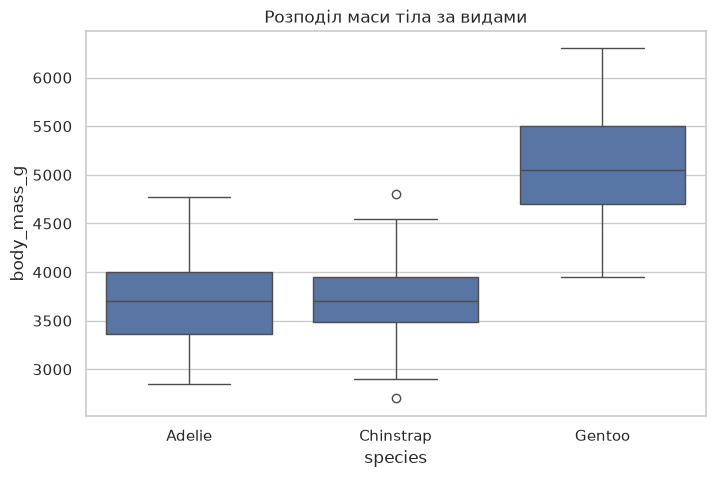

In [12]:
sns.boxplot(data=df_clean, x='species', y='body_mass_g')
plt.title('Розподіл маси тіла за видами')
plt.show()

### 5.2 Довжина та глибина дзьоба — scatter за видами

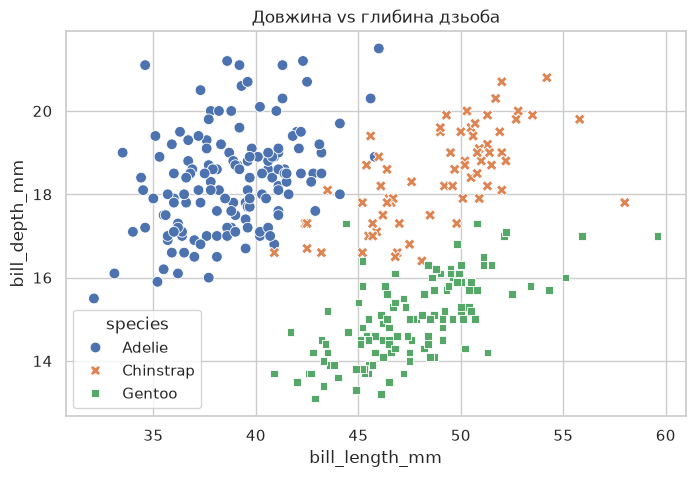

In [13]:
sns.scatterplot(data=df_clean, x='bill_length_mm', y='bill_depth_mm',
                hue='species', style='species', s=60)
plt.title('Довжина vs глибина дзьоба')
plt.show()

### 5.3 Кореляційна матриця числових ознак

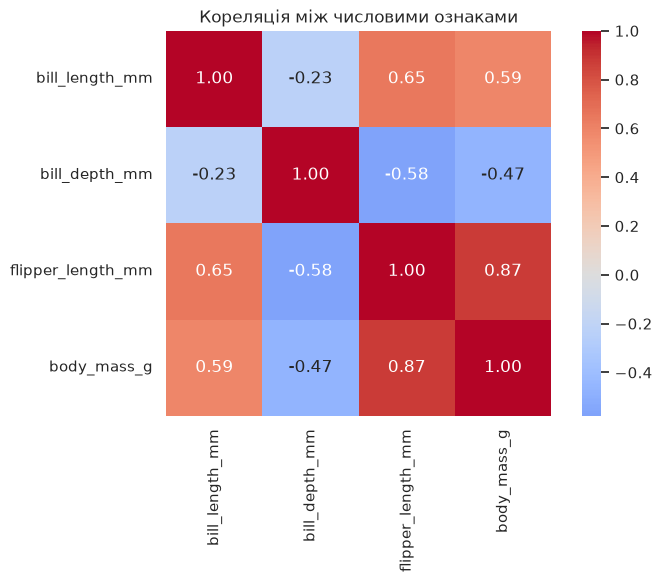

In [14]:
corr = df_clean[num_cols].corr()
sns.heatmap(corr, annot=True, cmap='coolwarm', center=0, fmt='.2f', square=True)
plt.title('Кореляція між числовими ознаками')
plt.show()

### 5.4 Парні залежності всіх числових ознак — pairplot

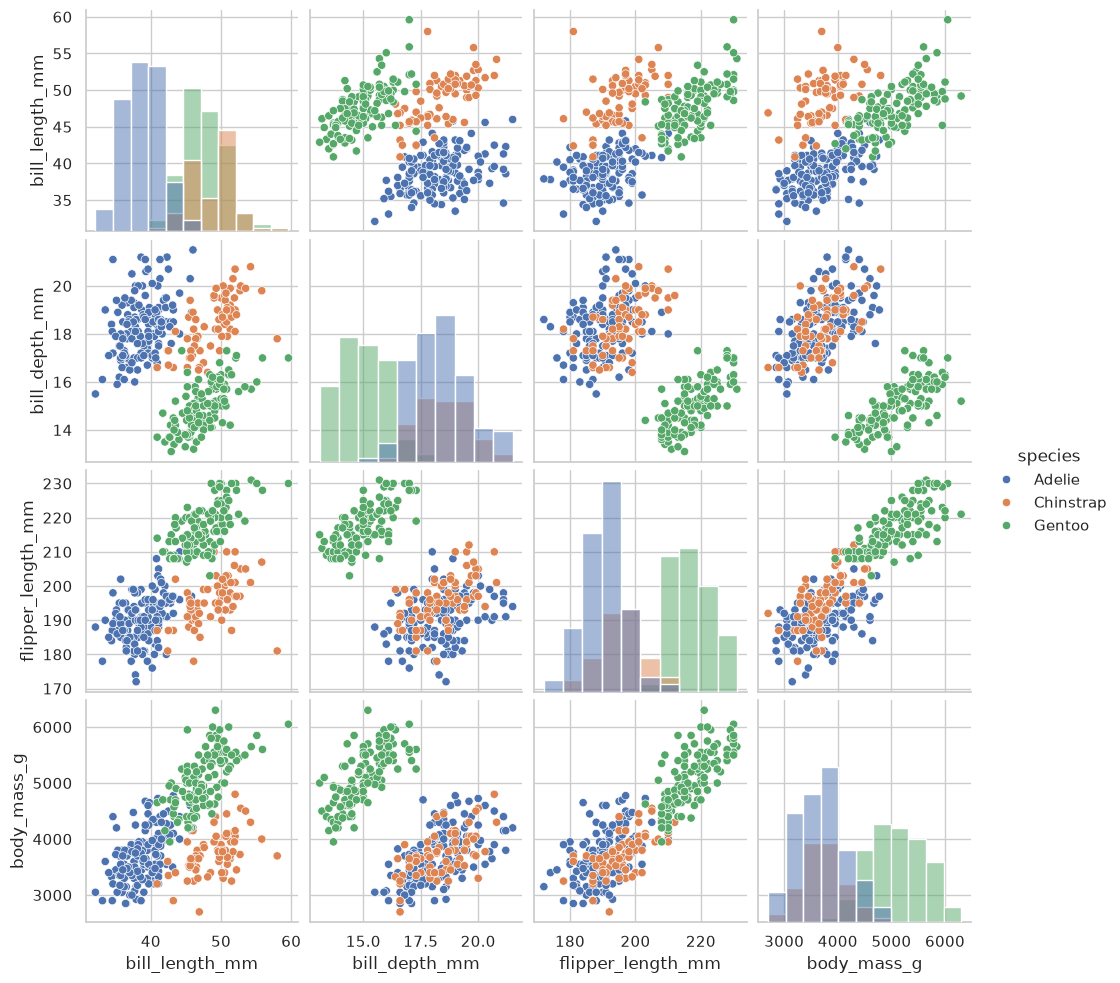

In [15]:
sns.pairplot(df_clean, hue='species', diag_kind='hist')
plt.show()

## 6. Висновки

> Заповни цей розділ власними спостереженнями після запуску всіх клітинок. Орієнтири:
>
> - Які види найкраще розрізняються за виміряними ознаками?
> - Яка пара числових ознак має найсильнішу кореляцію (дивись heatmap)?
> - Чи видно на scatter/pairplot чіткі кластери, що відповідають видам?
> - Чи збалансовані класи (кількість пінгвінів кожного виду)?
> - Як маса тіла відрізняється між видами (boxplot)?
